# Multi Unconfoundedness

Multi Unconfoundedness is observational/quasi experimental scenario of causal inference with multiple treatments. Treatments are not randomly assigned so we need to control confounders to estimate causal effect

# Data

In our research we should estimate effect of different gamification mechanics.
Our outcome is number of sessions per month.

Treatments:
- d_0: No mechanics used
- d_1: Used first set of mechanics
- d_2: Used second set of mechanics

DGP is from Causalis. Read more at https://causalis.causalcraft.com/articles/generate_multitreatment_gamma_26

In [1]:
from causalis.scenarios.multi_unconfoundedness.dgp import generate_multitreatment_gamma_26

df = generate_multitreatment_gamma_26(return_causal_data=False, include_oracle=True)

In [2]:
df.head()

,y,d_0,d_1,d_2,tenure_months,avg_sessions_week,spend_last_month,premium_user,urban_resident,support_tickets_q,...,m_obs_d_1,tau_link_d_1,m_d_2,m_obs_d_2,tau_link_d_2,g_d_0,g_d_1,g_d_2,cate_d_1,cate_d_2
0,0.422769,1.0,0.0,0.0,27.656605,3.198667,89.609464,0.0,1.0,0.0,...,0.241488,-0.352005,0.238966,0.238966,0.494166,3.279384,2.306314,5.375338,-0.973070,2.095954
1,7.566231,1.0,0.0,0.0,23.798386,3.362415,102.337236,0.0,0.0,3.0,...,0.193327,-0.307360,0.179820,0.179820,0.420278,2.807850,2.064853,4.274630,-0.742997,1.466780
2,1.702662,0.0,0.0,1.0,28.425009,3.391819,102.660712,0.0,1.0,1.0,...,0.202172,-0.320189,0.251262,0.251262,0.502415,3.069919,2.228798,5.073677,-0.841121,2.003758
3,1.827530,1.0,0.0,0.0,18.860066,4.071175,83.593417,0.0,0.0,2.0,...,0.182115,-0.316241,0.216446,0.216446,0.441677,2.716805,1.980234,4.225485,-0.736571,1.508680
4,1.429843,0.0,1.0,0.0,17.853087,3.140075,79.209870,0.0,1.0,1.0,...,0.234004,-0.350130,0.243901,0.243901,0.493624,3.224354,2.271869,5.282273,-0.952485,2.057919


In [3]:
print(f"Ground truth ATE for d_1 vs d_0 is {df['cate_d_1'].mean()}")
print(f"Ground truth ATE for d_2 vs d_0 is {df['cate_d_2'].mean()}")

Ground truth ATE for d_1 vs d_0 is -1.1950325692907122
Ground truth ATE for d_2 vs d_0 is 2.530398527003894


In [4]:
print(f"Ground truth ATTE for d_1 vs d_0 is {df[df['d_1']==1]['cate_d_1'].mean()}")
print(f"Ground truth ATTE for d_2 vs d_0 is {df[df['d_2']==1]['cate_d_2'].mean()}")

Ground truth ATTE for d_1 vs d_0 is -1.3206565011256086
Ground truth ATTE for d_2 vs d_0 is 2.6566253524753014


In [5]:
# wrap it in MultiCausalData
from causalis.data_contracts.multicausaldata import MultiCausalData
multi_causaldata = MultiCausalData(
    df=df,
    treatment_names=['d_0', 'd_1', 'd_2'],
    control_treatment='d_0',
    outcome='y',
    confounders=[
        'tenure_months', 'avg_sessions_week', 'spend_last_month', 'premium_user',
        'urban_resident', 'support_tickets_q', 'discount_eligible', 'credit_utilization'
    ]
)
multi_causaldata

MultiCausalData(df=(100000, 12), treatment_names=['d_0', 'd_1', 'd_2'], control_treatment='d_0')outcome='y', confounders=['tenure_months', 'avg_sessions_week', 'spend_last_month', 'premium_user', 'urban_resident', 'support_tickets_q', 'discount_eligible', 'credit_utilization'], user_id=None, 

# EDA

In [6]:
from causalis.shared import outcome_stats
outcome_stats(multi_causaldata)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,d_0,50116,3.742732,3.079399,0.015427,0.886736,1.621920,2.928251,4.946985,7.549669,50.239323
1,d_2,25115,6.674511,5.732372,0.043125,1.525792,2.813865,5.173799,8.733119,13.649046,79.125235
2,d_1,24769,2.972424,2.398112,0.009022,0.713586,1.312453,2.351314,3.929862,5.982750,25.169272


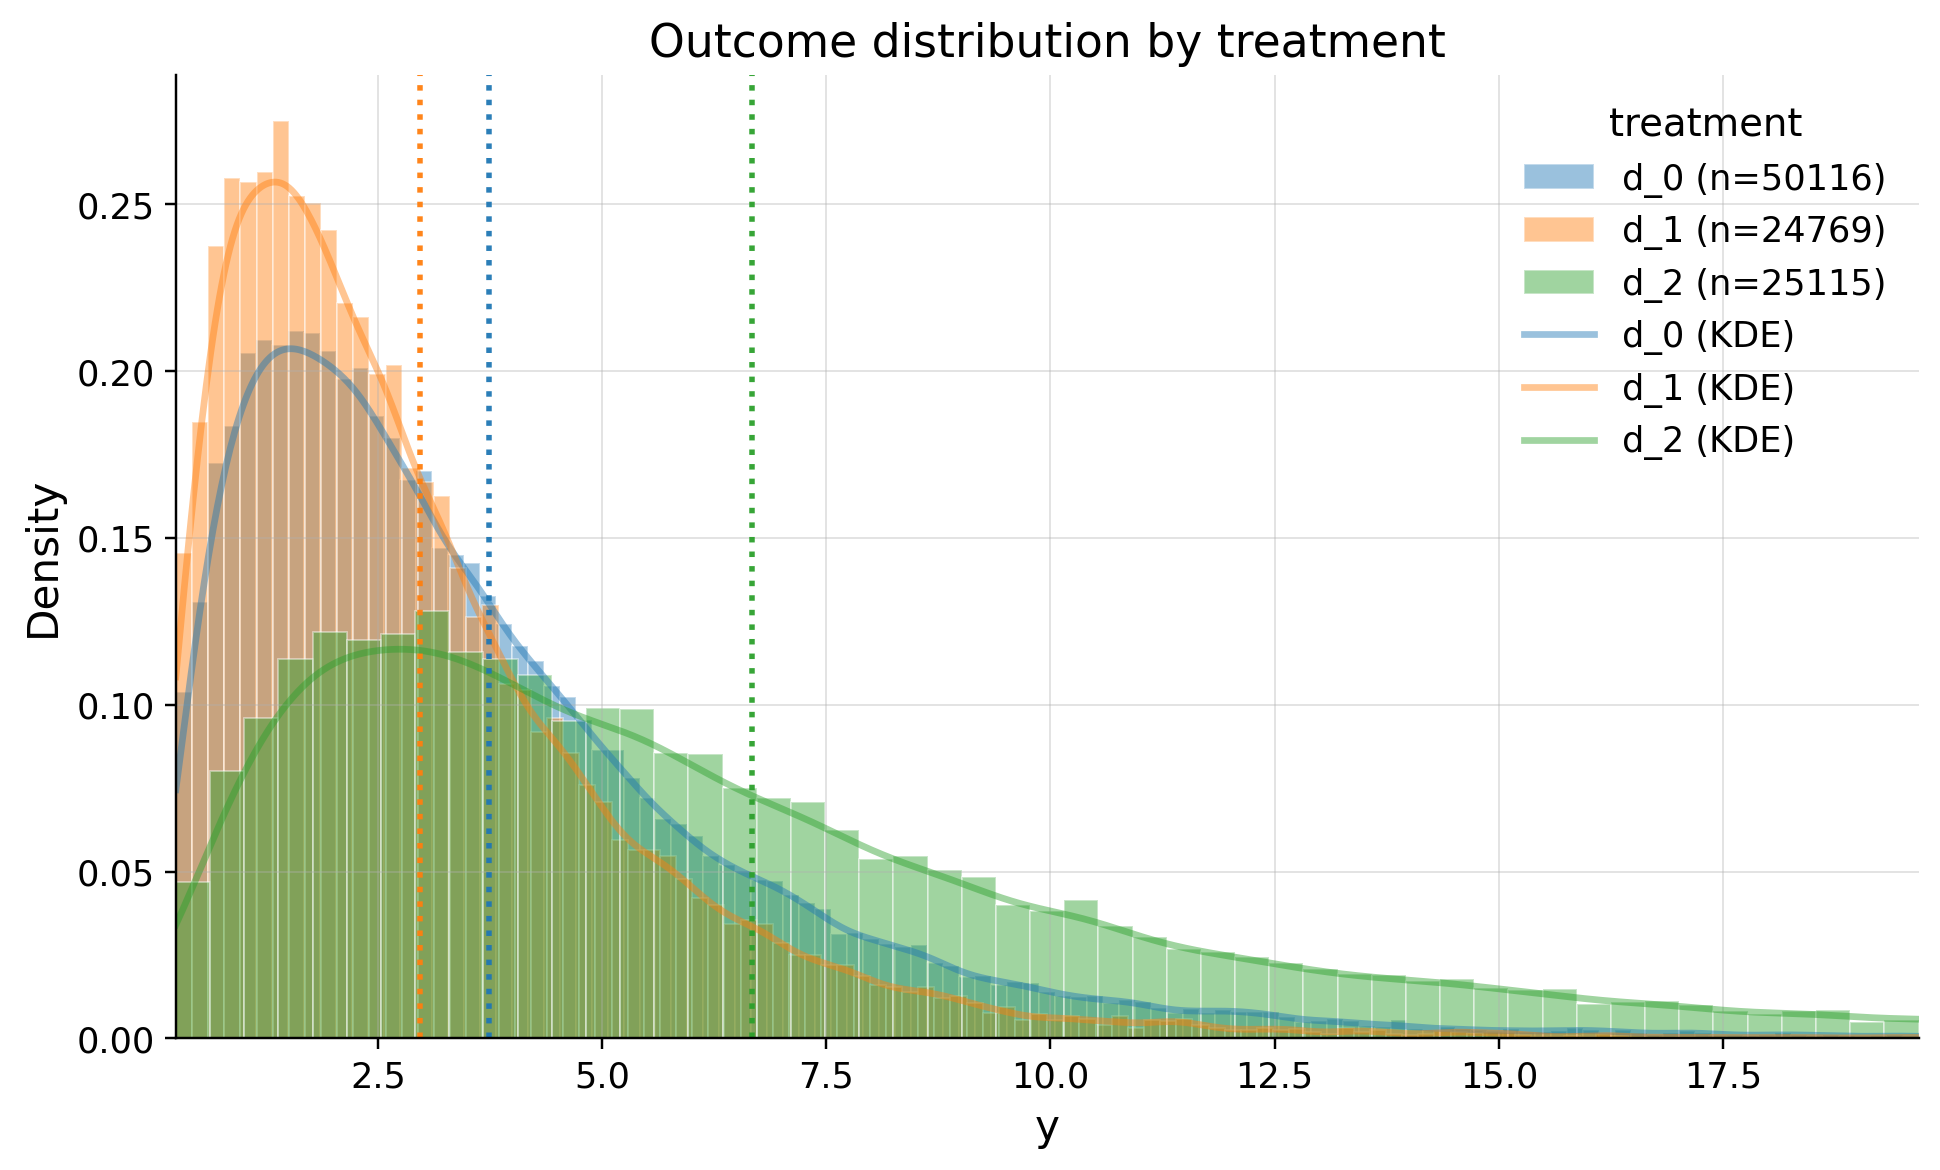

In [7]:
from causalis.shared.outcome_plots import outcome_plot_dist
outcome_plot_dist(multi_causaldata)

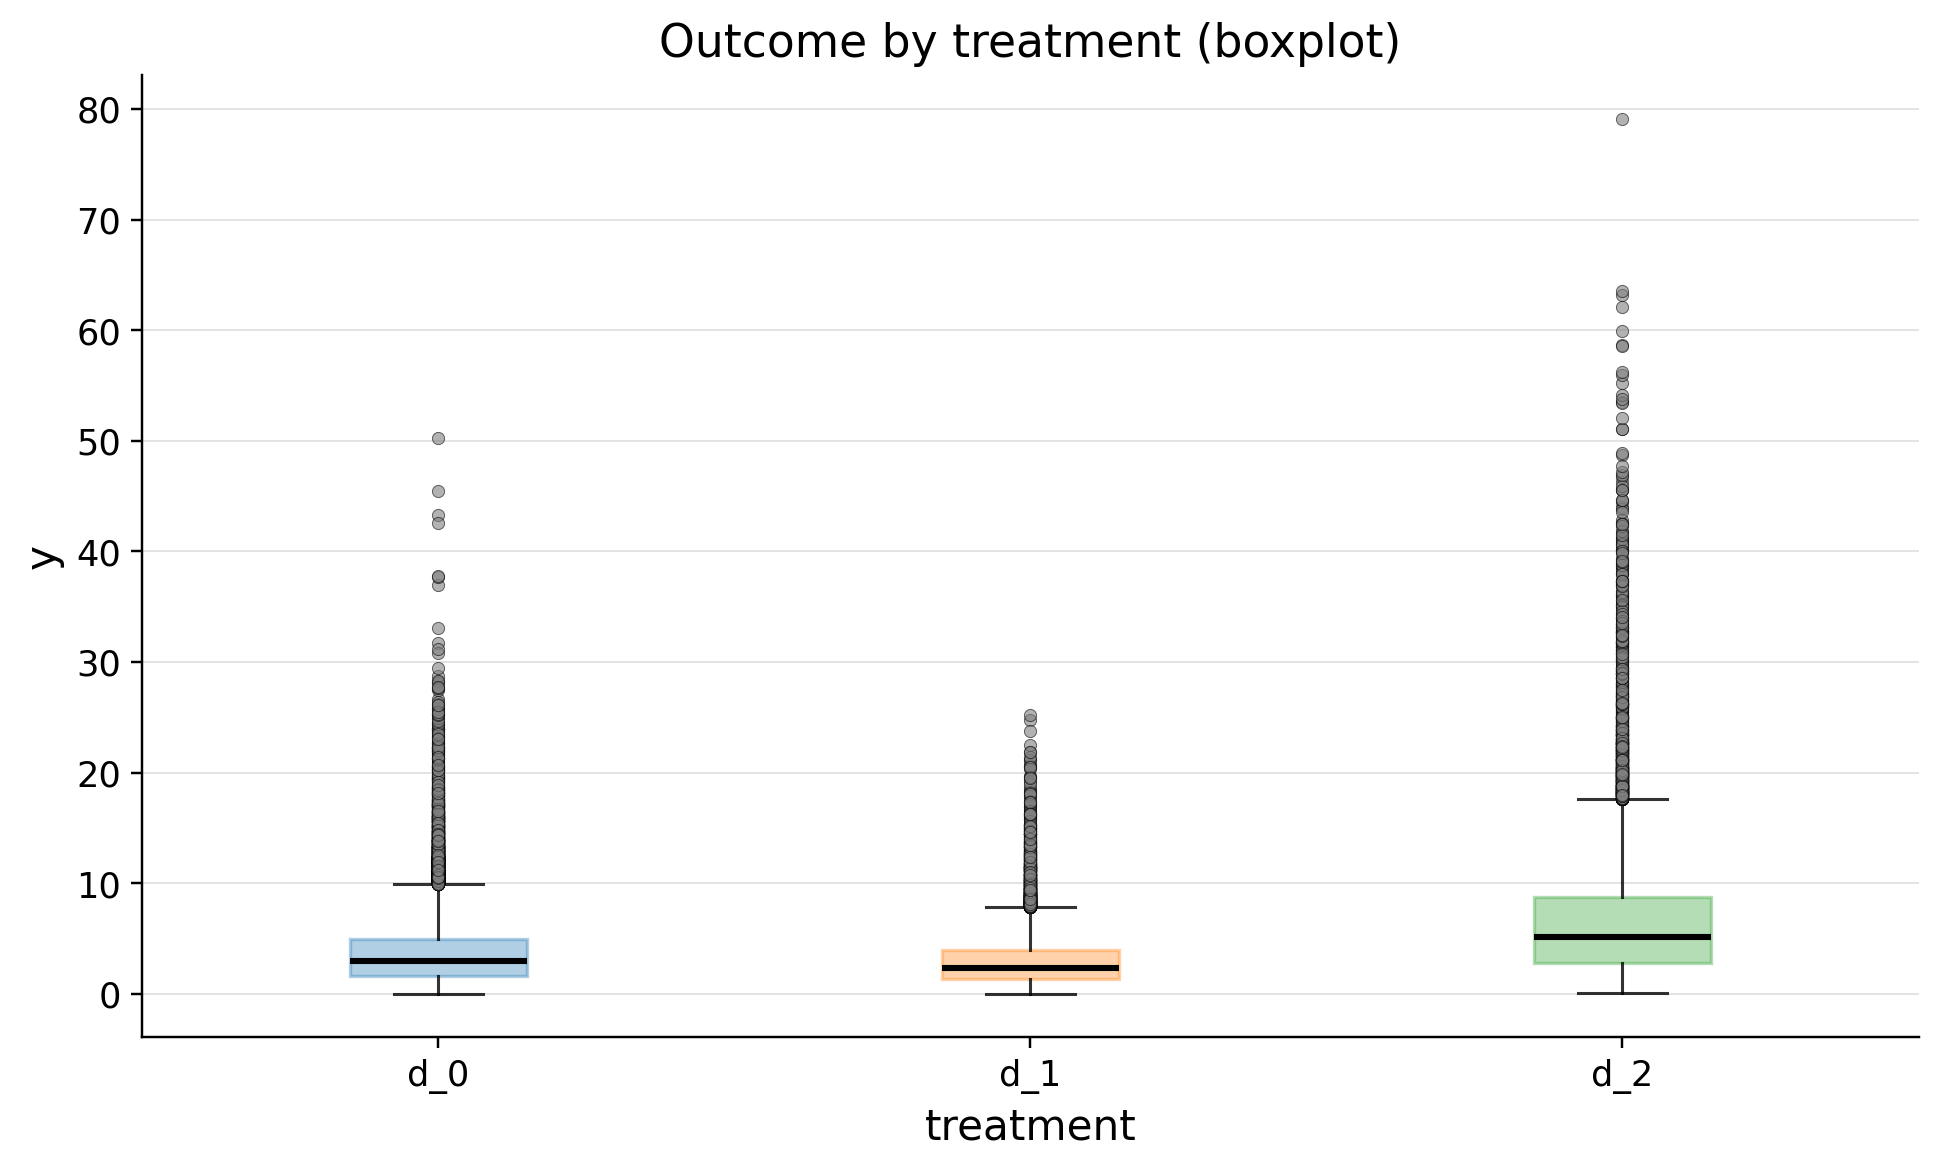

In [8]:
from causalis.shared.outcome_plots import outcome_plot_boxplot
outcome_plot_boxplot(multi_causaldata)

In [9]:
from causalis.shared import outcome_outliers

outcome_outliers(multi_causaldata)

,treatment,n,outlier_count,outlier_rate,lower_bound,upper_bound,has_outliers,method,tail
0,d_0,50116,2245,0.044796,-3.365678,9.934583,True,iqr,both
1,d_2,25115,1204,0.047939,-6.065015,17.611999,True,iqr,both
2,d_1,24769,1077,0.043482,-2.613661,7.855976,True,iqr,both


As we see there are heavy tails in distribution of outcome. We won't trim them because high activity means high income of revenue for us

In [10]:
from causalis.shared import confounders_balance

confounders_balance(multi_causaldata, 'd_0', 'd_1')

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,avg_sessions_week,4.763117,5.256036,0.492919,0.249505,0.00000
1,premium_user,0.226734,0.313981,0.087247,0.197390,0.00000
2,tenure_months,23.650535,25.717739,2.067204,0.175404,0.00000
3,discount_eligible,0.332449,0.403973,0.071524,0.148699,0.00000
4,spend_last_month,80.419388,92.251285,11.831897,0.139885,0.00000
5,urban_resident,0.572332,0.626711,0.054379,0.111147,0.00000
6,support_tickets_q,1.533163,1.550608,0.017445,0.013964,0.04860
7,credit_utilization,0.448521,0.448870,0.000349,0.003211,0.73664


In [11]:
confounders_balance(multi_causaldata, 'd_0', 'd_2')

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,avg_sessions_week,4.763117,5.263046,0.499928,0.252342,0.00000
1,spend_last_month,80.419388,98.061742,17.642354,0.201558,0.00000
2,urban_resident,0.572332,0.643480,0.071148,0.146116,0.00000
3,support_tickets_q,1.533163,1.401752,0.131411,-0.108686,0.00000
4,credit_utilization,0.448521,0.454175,0.005655,0.052068,0.00000
5,premium_user,0.226734,0.238742,0.012008,0.028418,0.01593
6,tenure_months,23.650535,23.479083,0.171451,-0.014732,0.02355
7,discount_eligible,0.332449,0.334820,0.002371,0.005029,0.99998


And data is highly biased by confounders

# Inference

In [12]:
from causalis.scenarios.multi_unconfoundedness import MultiTreatmentIRM

model = MultiTreatmentIRM().fit(multi_causaldata)

## Explanation of `MultiTreatmentIRM`


### 0) Assumptions


- **SUTVA / consistency**: no interference, no hidden treatment versions, and observed outcome equals the potential outcome under realized arm.
- **Multi-arm unconfoundedness**:
$$
\left(Y(0),Y(1),\dots,Y(K-1)\right) \perp D \mid X
$$
where $D$ is one-hot with baseline arm $D_0$.
- **Positivity / overlap**:
$$
\Pr(D_k=1\mid X=x)>0,\quad \forall k=0,\dots,K-1.
$$
In practice, the implementation enforces stability with propensity trimming.


### 1) Data and estimand


For each unit $i$ we observe $(Y_i, X_i, D_i)$ with one-hot $D_i=(D_{i0},\dots,D_{i,K-1})$ and $\sum_k D_{ik}=1$.

`MultiTreatmentIRM` estimates vector contrasts against baseline:
$$
\theta_k = \mathbb{E}[Y(k)-Y(0)],\quad k=1,\dots,K-1.
$$
So outputs are pairwise ATEs such as `d_1 vs d_0`, `d_2 vs d_0`.


### 2) Nuisance functions


For each arm $k$:
$$
g_k(x)=\mathbb{E}[Y\mid X=x, D_k=1],\qquad
m_k(x)=\Pr(D_k=1\mid X=x),\ \sum_{k=0}^{K-1}m_k(x)=1.
$$
These are estimated out-of-fold by cross-fitting (to reduce overfitting bias in final moments).


### 3) Cross-fitting logic


With folds $I_1,\dots,I_F$:
1. Train multiclass propensity model on $I_f^c$, predict $\hat m_k$ on $I_f$.
2. For each arm $k$, train outcome model on rows in $I_f^c$ where $D_k=1$, predict $\hat g_k$ on $I_f$.
3. Repeat for all folds and stitch predictions.


### 4) Multiclass trimming


Predicted propensities are stabilized by lower-bound trimming and row renormalization:
$$
\tilde m_{ik}=\max(\hat m_{ik},\varepsilon),\qquad
\hat m^{trim}_{ik}=\frac{\tilde m_{ik}}{\sum_{j=0}^{K-1}\tilde m_{ij}}.
$$
This keeps each row on the probability simplex and avoids exploding IPW weights.


### 5) Orthogonal score for each contrast


Define residuals and IPW representers:
$$
u_{ik}=Y_i-\hat g_k(X_i),\qquad
h_{ik}=\frac{D_{ik}}{\hat m^{trim}_{ik}}.
$$
(If `normalize_ipw=True`, $h_{ik}$ is column-normalized in Hajek style.)

For each active arm $k>0$ vs baseline $0$:
$$
\psi_{b,ik}=\big(\hat g_k(X_i)-\hat g_0(X_i)\big)+u_{ik}h_{ik}-u_{i0}h_{i0},
\qquad \psi_a=-1.
$$
Moment condition:
$$
\mathbb{E}_n[\psi_a\theta_k+\psi_{b,\cdot k}]=0
\ \Rightarrow\
\hat\theta_k=\mathbb{E}_n[\psi_{b,\cdot k}].
$$


### 6) Inference


Influence function per contrast:
$$
\widehat{IF}_{ik}=\psi_{b,ik}-\hat\theta_k.
$$
Then
$$
\widehat{SE}(\hat\theta_k)=\sqrt{\frac{\mathrm{Var}_n(\widehat{IF}_{\cdot k})}{n}},
$$
with Wald CI
$$
\hat\theta_k \pm z_{1-\alpha/2}\widehat{SE}(\hat\theta_k).
$$
P-values are normal-approximation; significance flag is Bonferroni-adjusted across $K-1$ contrasts.


### 7) Relative effect reported by the model


Baseline mean is estimated via orthogonal signal:
$$
\psi_{\mu_c,i}=\hat g_0(X_i)+u_{i0}h_{i0},\qquad \hat\mu_c=\mathbb{E}_n[\psi_{\mu_c}].
$$
Relative effect (%):
$$
\hat\tau_k^{rel}=100\cdot\frac{\hat\theta_k}{\hat\mu_c},
$$
with CI from delta-method variance (as implemented in `model.py`).


In [13]:
dml_result = model.estimate(score='ATTE')
dml_result.summary()

,d_1 vs d_0,d_2 vs d_0
field,,
estimand,ATTE,ATTE
model,MultiTreatmentIRM,MultiTreatmentIRM
value,"-1.2880 (ci_abs: -1.3405, -1.2356)","2.6385 (ci_abs: 2.5586, 2.7185)"
value_relative,"-30.2320 (ci_rel: -31.1739, -29.2900)","65.3759 (ci_rel: 63.1892, 67.5627)"
alpha,0.0500,0.0500
p_value,0.0000,0.0000
is_significant,True,True
n_treated,24769,25115
n_control,50116,50116


# Refutation

## Unconfoundedness

In [14]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness import run_unconfoundedness_diagnostics
rep_uc = run_unconfoundedness_diagnostics(multi_causaldata, dml_result)
rep_uc["summary"]  # comparison, metric, value, flag

ValueError: Only ATE is supported for multi-treatment unconfoundedness diagnostics. Got score='ATTE'.

## Sensitivity

In [ ]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness.sensitivity import (
    sensitivity_analysis, get_sensitivity_summary
)

In [ ]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness import sensitivity_benchmark


bench = sensitivity_benchmark(dml_result, benchmarking_set=["tenure_months"])
bench

In [ ]:
res = sensitivity_analysis(
    dml_result,  # MultiCausalEstimate
    multi_causaldata,  # MultiCausalData (optional but recommended for validation)
    cf_y=0.05,  # confounding strength in outcome residual
    r2_d=0.05,  # confounding strength in treatment residual
    rho=1.0,
    H0=0.0,
    alpha=0.05,
)

res

## Overlap

In [ ]:
from causalis.scenarios.multi_unconfoundedness.refutation.overlap import overlap_plot

overlap_plot(multi_causaldata,dml_result)

In [ ]:
from causalis.scenarios.multi_unconfoundedness.refutation.overlap import run_overlap_diagnostics
rep_overlap = run_overlap_diagnostics(multi_causaldata, dml_result)
rep_overlap["summary"]

## SUTVA

In [ ]:
from causalis.shared import print_sutva_questions
print_sutva_questions()

## Score

In [ ]:
from causalis.scenarios.multi_unconfoundedness.refutation.score import run_score_diagnostics
rep_overlap = run_score_diagnostics(multi_causaldata, dml_result)
rep_overlap["summary"]

In [ ]:
from causalis.scenarios.multi_unconfoundedness.refutation import plot_residual_diagnostics
plot_residual_diagnostics(dml_result)

# Conclusion

Set of mechanics labeled d_2 performed better and has effect 2.5355 (ci_abs: 2.4600, 2.6111) sessions per user. However, set of mechanics labeled d_1 perform worse than without mechanics -1.1772 (ci_abs: -1.2174, -1.1370) sessions. We need to turn them off